In [83]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from flowtorch.data import FOAMDataloader, mask_box
from flowtorch.rom import CNM, SVDEncoder

# increase resolution of plots
mpl.rcParams['figure.dpi'] = 160

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30388/1207954830.py:3: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(path, skiprows=12, header=0, sep="\s+", usecols=[0,1,4], names=names)


,t,cd,cl
0,0.002,1.789333,0.000271
1,0.004,0.762851,0.000417
2,0.006,0.627570,-0.000169
3,0.008,0.574870,-0.000452
4,0.010,0.527739,-0.000546
...,...,...,...
4995,9.992,0.378504,0.022828
4996,9.994,0.378506,0.023938
4997,9.996,0.378506,0.024989
4998,9.998,0.378517,0.026094


[]

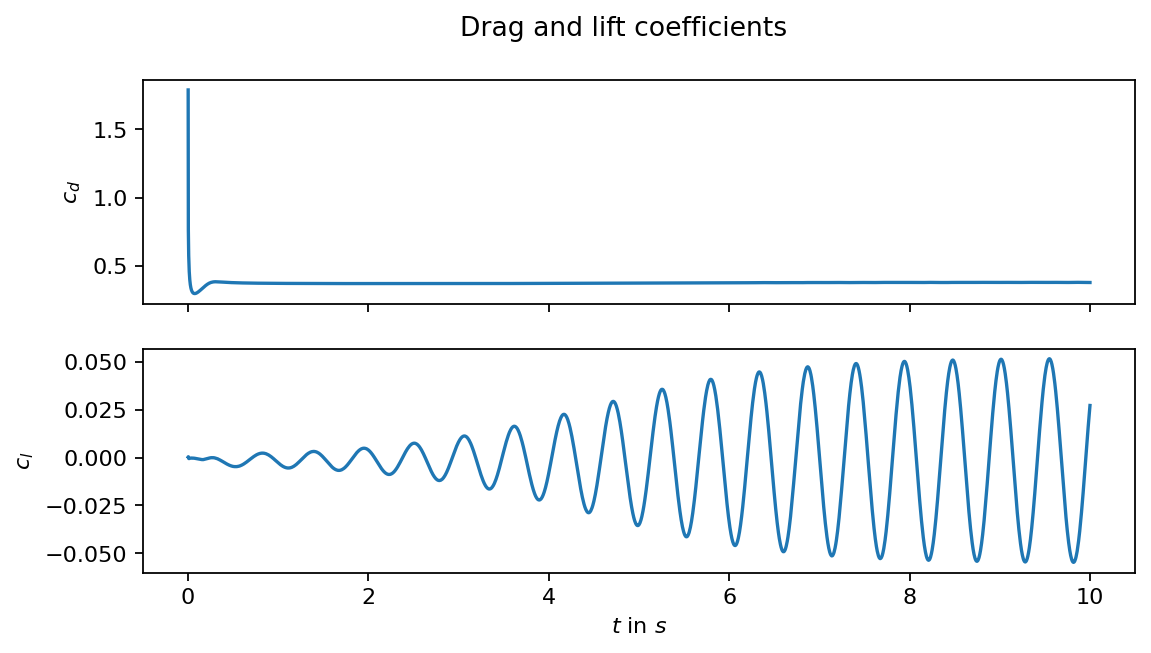

In [84]:


path = "cylinder2D_Re200/postProcessing/forces/0/coefficient.dat"
names = ["t", "cd", "cl"]
data = pd.read_csv(path, skiprows=12, header=0, sep="\s+", usecols=[0,1,4], names=names)
display(data)

plt.rcParams["figure.dpi"] = 160

# plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
fig.suptitle("Drag and lift coefficients")

ax1.plot(data.t, data.cd)
ax2.plot(data.t, data.cl)
ax2.set_xlabel(r"$t$ in $s$")
ax2.set_ylabel(r"$c_l$")
ax1.set_ylabel(r"$c_d$")
plt.savefig("drag_and_lift.png", bbox_inches="tight")
plt.plot()



In [85]:
case = "cylinder2D_Re200"
loader = FOAMDataloader(case)
times = loader.write_times
window_times = [t for t in times if float(t) >= 1.0] # t > 1

# load vertices, discard z-coordinate, and create a mask
vertices = loader.vertices[:, :2]
mask = mask_box(vertices, lower=[0, 0], upper=[1.0, 0.4])

# assemble data matrix
data_matrix = torch.zeros((mask.sum().item(), len(window_times)), dtype=torch.float32)
for i, time in enumerate(window_times):
    U = loader.load_snapshot("U", time)
    Umag = torch.linalg.norm(U[:, :2], dim=1)
    data_matrix[:, i] = torch.masked_select(Umag, mask)


[2026-01-21 15:18:28] WARNING  Could not find precomputed cell centers and volumes (processor0).
Computing cell geometry from scratch (slow, not recommended for large meshes).
To compute cell centers and volumes in OpenFOAM, use:

runParallel postProcess -func "writeCellCentres" -constant -time none
runParallel postProcess -func "writeCellVolumes" -constant -time none



[2026-01-21 15:18:28] WARNING  Could not find precomputed cell centers and volumes (processor1).
Computing cell geometry from scratch (slow, not recommended for large meshes).
To compute cell centers and volumes in OpenFOAM, use:

runParallel postProcess -func "writeCellCentres" -constant -time none
runParallel postProcess -func "writeCellVolumes" -constant -time none



In [94]:
encoder = SVDEncoder(rank=30)
info = encoder.train(data_matrix)
reduced_state = encoder.encode(data_matrix)
print(f"Reduced state shape: {reduced_state.shape}")
print("Training time: {:2.4f}s".format(info["execution_time"]))

Reduced state shape: torch.Size([30, 281])
Training time: 0.0251s


In [95]:
dt = float(times[1]) - float(times[0])
cnm = CNM(reduced_state, encoder, dt, n_clusters=40, model_order=4)
print(f"Time step between snapshots: {dt}s")

Time step between snapshots: 0.032s


In [96]:
clusters = cnm.cluster_centers
clusters_reconstructed = encoder.decode(torch.from_numpy(clusters.T))

In [97]:
def add_mode(ax, mode, title, every=4):
    ax.tricontourf(x[::every], y[::every], mode[::every], levels=15, cmap="jet")
    ax.tricontour(x[::every], y[::every], mode[::every], levels=15, linewidths=0.1, colors='k')
    ax.add_patch(plt.Circle((0.2, 0.2), 0.05, color='k'))
    ax.set_aspect("equal", 'box')
    ax.set_title(title)

x = torch.masked_select(vertices[:, 0], mask)
y = torch.masked_select(vertices[:, 1], mask)

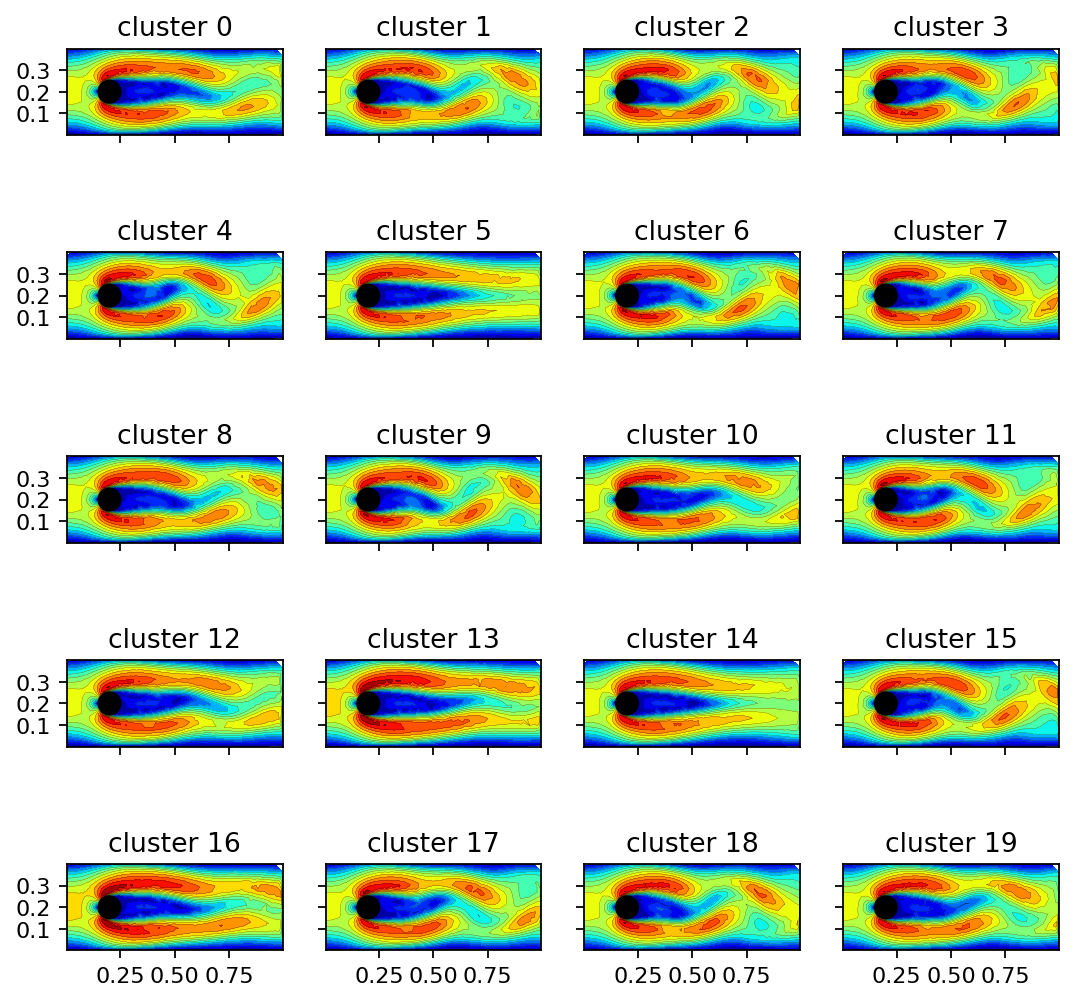

In [98]:
fig, axarr = plt.subplots(5, 4, figsize=(8, 8), sharex=True, sharey=True)
count = 0
for row in range(5):
    for col in range(4):
        add_mode(axarr[row, col], clusters_reconstructed[:, count], f"cluster {count}")
        count += 1
plt.show()

In [99]:
prediction = cnm.predict(data_matrix[:, :5], 1.0, dt)

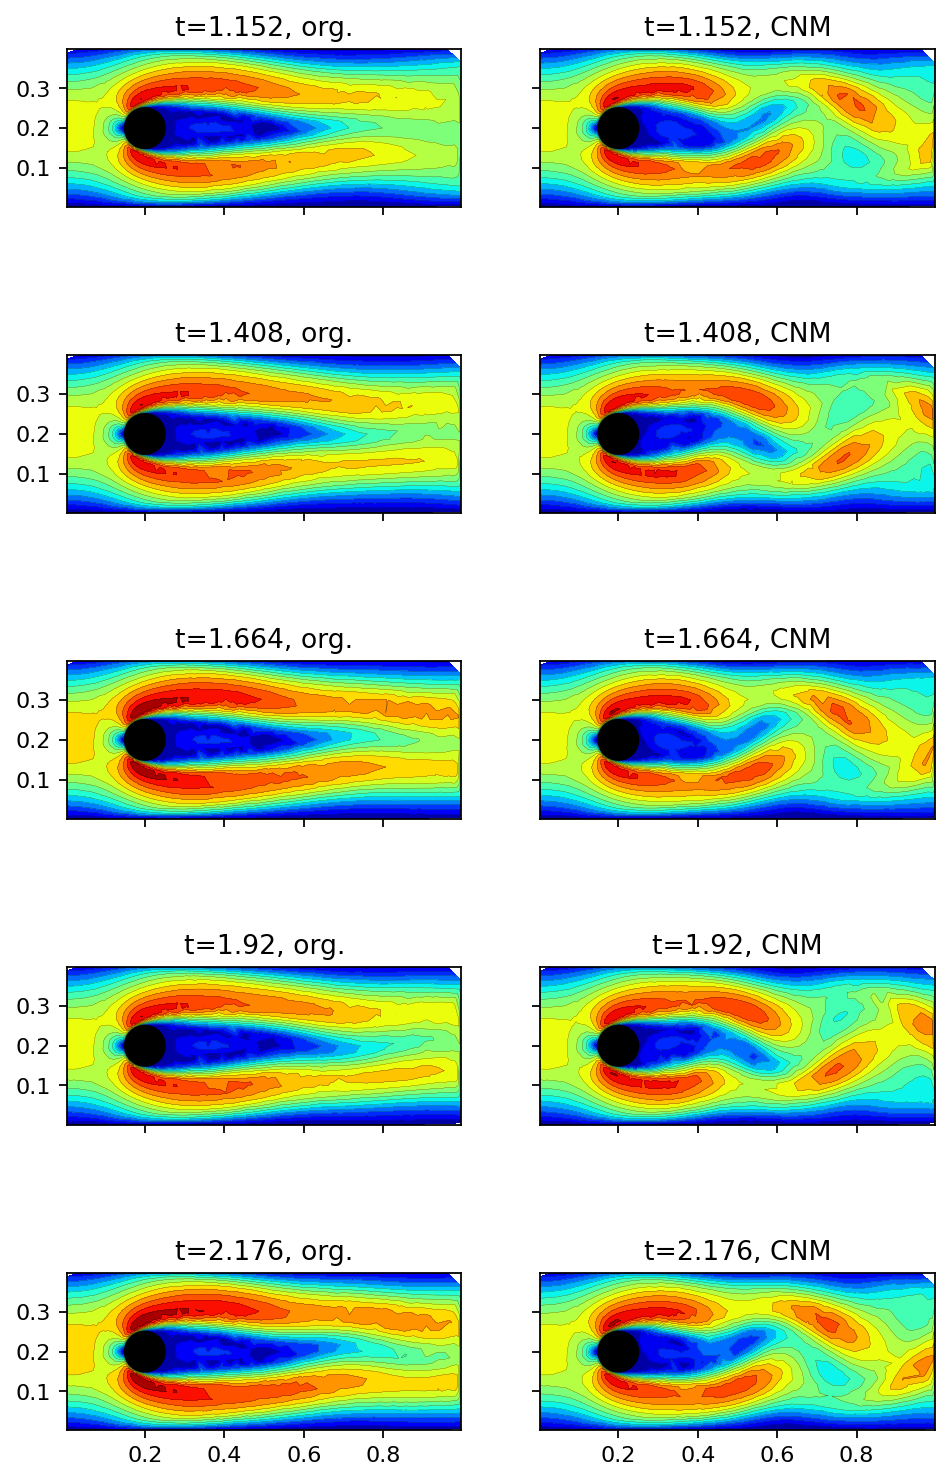

In [100]:
fig, axarr = plt.subplots(5, 2, figsize=(7, 12), sharex=True, sharey=True)

n_pred = prediction.shape[1]     # 33
n_rows = 5

# wähle 5 indices gleichmäßig über die prediction verteilt
idxs = np.linspace(0, n_pred-1, n_rows, dtype=int)

for row, k in enumerate(idxs):
    add_mode(axarr[row, 0], data_matrix[:, 4+k], f"t={window_times[4+k]}, org.")
    add_mode(axarr[row, 1], prediction[:, k],   f"t={window_times[4+k]}, CNM")

plt.show()
